# L1.5 — The multirotor kinematics

**Level 1 · Core · 45 minutes**

**Goal.** You can move one multirotor for one step, and for many steps.

**Check at the end.** You can say what a holonomic point mass permits that a fixed-wing cannot do.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The step contract

One method, and it is a pure function. It reads a state and returns a new state. It changes nothing.

```python
Multirotor().step(state, command, perf, dt, wind=NO_WIND) -> AircraftState
```

To fly for many steps, call it in a loop and keep the result each time. This is exactly what
`run_fleet` does for you in Level 2.

The `Multirotor` is a **holonomic point mass**. It can move in any direction at once, and it can
turn its nose apart from its direction of travel. It does not bank.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c"

from opencdarr import M600, MotionCommand, create_aircraft, geo
from opencdarr.kinematics import Multirotor

MR = Multirotor()


def fly(state, command, n: int, dt: float = 1.0, perf=M600):
    """Hold one command for n steps. Return every state, the start included."""
    out = [state]
    for _ in range(n):
        cmd = command(out[-1]) if callable(command) else command
        out.append(MR.step(out[-1], cmd, perf, dt))
    return out


start = create_aircraft(M600, id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=10.0)
one = MR.step(start, MotionCommand.from_track_speed(0.0, 10.0), M600, dt=1.0)

print(f"{'field':<18}{'before':>14}{'after 1 s':>14}")
for name in ("lat", "lon", "trk", "gs", "flight_time", "distance_flown"):
    print(f"{name:<18}{getattr(start, name):>14.6f}{getattr(one, name):>14.6f}")

field                     before     after 1 s
lat                    52.000000     52.000090
lon                     4.000000      4.000000
trk                     0.000000      0.000000
gs                     10.000000     10.000000
flight_time             0.000000      1.000000
distance_flown          0.000000     10.000000


## 2. Fly a track

Give one velocity command and hold it. Then change it. Use `geo.enu` to draw the result in metres.

In [2]:
leg1 = fly(start, MotionCommand.from_track_speed(0.0, 12.0), 30)      # north for 30 s
leg2 = fly(leg1[-1], MotionCommand.from_track_speed(90.0, 12.0), 30)  # then east for 30 s
track = leg1 + leg2[1:]

origin = (start.lat, start.lon)
xy = np.array([geo.enu(*origin, s.lat, s.lon) for s in track])

print(f"steps flown        {len(track) - 1}")
print(f"flight time        {track[-1].flight_time:.0f} s")
print(f"distance flown     {track[-1].distance_flown:.0f} m")
print(f"final track        {track[-1].trk:.1f} deg at {track[-1].gs:.1f} m/s")

steps flown        60
flight time        60 s
distance flown     712 m
final track        90.0 deg at 12.0 m/s


## 3. The two limits that shape every manoeuvre

`v_max` clamps a speed request. `ax` limits how fast the speed may change, so a step in the command
becomes a ramp in the flight.

Ask the M600 for 30 m/s. Its `v_max` is 18 m/s and its `ax` is 5 m/s², so it takes about four
seconds to arrive at a speed it will then hold.

In [3]:
from_rest = create_aircraft(M600, id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=0.0)
ramp = fly(from_rest, MotionCommand.from_track_speed(0.0, 30.0), 10)

print(f"commanded 30.0 m/s, v_max is {M600.v_max} m/s, ax is {M600.ax} m/s^2\n")
for k, s in enumerate(ramp):
    note = "  <- clamped at v_max" if abs(s.gs - M600.v_max) < 1e-9 else ""
    print(f"  t = {k:>2} s   gs {s.gs:6.2f} m/s{note}")

commanded 30.0 m/s, v_max is 18.0 m/s, ax is 5.0 m/s^2

  t =  0 s   gs   0.00 m/s
  t =  1 s   gs   5.00 m/s
  t =  2 s   gs  10.00 m/s
  t =  3 s   gs  15.00 m/s
  t =  4 s   gs  18.00 m/s  <- clamped at v_max
  t =  5 s   gs  18.00 m/s  <- clamped at v_max
  t =  6 s   gs  18.00 m/s  <- clamped at v_max
  t =  7 s   gs  18.00 m/s  <- clamped at v_max
  t =  8 s   gs  18.00 m/s  <- clamped at v_max
  t =  9 s   gs  18.00 m/s  <- clamped at v_max
  t = 10 s   gs  18.00 m/s  <- clamped at v_max


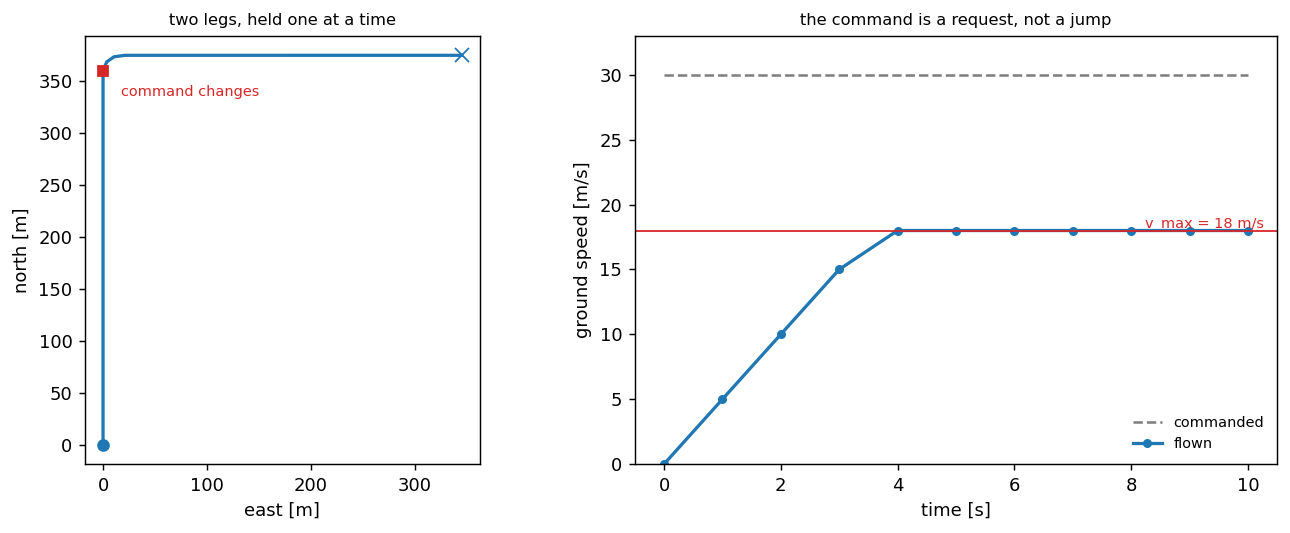

In [4]:
fig, (ax_xy, ax_v) = plt.subplots(1, 2, figsize=(10.6, 4.2))

ax_xy.plot(xy[:, 0], xy[:, 1], lw=1.8, color=BLUE)
ax_xy.plot(xy[0, 0], xy[0, 1], marker="o", ms=6, color=BLUE)
ax_xy.plot(xy[-1, 0], xy[-1, 1], marker="x", ms=8, color=BLUE)
ax_xy.plot(xy[30, 0], xy[30, 1], marker="s", ms=5, color=RED)
ax_xy.annotate("command changes", xy[30], (10, -14), textcoords="offset points",
               fontsize=8, color=RED)
ax_xy.set_aspect("equal")
ax_xy.set_xlabel("east [m]")
ax_xy.set_ylabel("north [m]")
ax_xy.set_title("two legs, held one at a time", fontsize=9)

t = np.arange(len(ramp))
ax_v.step(t, [30.0] * len(ramp), where="post", lw=1.4, ls="--", color=GREY, label="commanded")
ax_v.plot(t, [s.gs for s in ramp], marker="o", ms=4, lw=1.8, color=BLUE, label="flown")
ax_v.axhline(M600.v_max, lw=1.0, color=RED)
ax_v.annotate(f"v_max = {M600.v_max:.0f} m/s", (0.98, M600.v_max), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color=RED)
ax_v.set_ylim(0, 33)
ax_v.set_xlabel("time [s]")
ax_v.set_ylabel("ground speed [m/s]")
ax_v.set_title("the command is a request, not a jump", fontsize=9)
ax_v.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()

## 4. Turn the nose without turning the flight

`target_yaw` commands the nose. `target_velocity` commands the travel. The two are independent, and
`yaw_rate_max` limits how fast the nose may turn.

This is what a camera-pointing mission needs: hold a heading on a target while you translate a
different way. A fixed-wing cannot do it, because its facing follows from its bank.

`yaw=None` on the state means the nose follows the track. As soon as you command a yaw, it becomes
a number and stays one.

The nose takes the **short way** round. From 0° toward 225° the short way is 135° to the left, so
the printed yaw goes 0, 315, 270, 225. That is three steps of −45°, not one jump of +315°. An angle
that wraps at 360 needs `np.unwrap` before you plot it.

In [5]:
DT = 0.5
holding = dataclasses.replace(from_rest, gs=10.0, trk=0.0, yaw=0.0)
turning = fly(holding, MotionCommand(target_velocity=(0.0, 10.0), target_yaw=225.0), 12, dt=DT)

print(f"yaw_rate_max is {M600.yaw_rate_max:.0f} deg/s, so at dt = {DT} s the nose may move "
      f"{M600.yaw_rate_max * DT:.0f} deg per step\n")
print(f"{'t [s]':>7}{'trk':>8}{'yaw':>8}{'gs':>8}")
for k, s in enumerate(turning):
    print(f"{k * DT:>7.1f}{s.trk:>8.1f}{s.yaw:>8.1f}{s.gs:>8.2f}")

yaw_rate_max is 90 deg/s, so at dt = 0.5 s the nose may move 45 deg per step

  t [s]     trk     yaw      gs
    0.0     0.0     0.0   10.00
    0.5     0.0   315.0   10.00
    1.0     0.0   270.0   10.00
    1.5     0.0   225.0   10.00
    2.0     0.0   225.0   10.00
    2.5     0.0   225.0   10.00
    3.0     0.0   225.0   10.00
    3.5     0.0   225.0   10.00
    4.0     0.0   225.0   10.00
    4.5     0.0   225.0   10.00
    5.0     0.0   225.0   10.00
    5.5     0.0   225.0   10.00
    6.0     0.0   225.0   10.00


## 5. Fly to a point

`target_position` is the goto channel. A multirotor flies straight to the point and then hovers. It
does not need `target_leg_start`, and it ignores `target_loiter_radius` — a fixed-wing needs both,
because it cannot stop.

Watch the ground speed. It ramps up under `ax`, holds at `v_max`, and ramps back down to zero on
arrival.

In [6]:
target = geo.forward(52.0, 4.0, 45.0, 300.0)           # 300 m to the north-east
goto = fly(from_rest, MotionCommand(target_position=target), 45)

dists = [geo.qdrdist(s.lat, s.lon, *target)[1] for s in goto]
print(f"{'t [s]':>7}{'gs [m/s]':>11}{'range to target [m]':>22}")
for k in (0, 5, 10, 15, 20, 25, 30, 45):
    print(f"{k:>7}{goto[k].gs:>11.2f}{dists[k]:>22.1f}")
print(f"\nit stops {dists[-1]:.1f} m from the point and hovers there")

  t [s]   gs [m/s]   range to target [m]
      0       0.00                 300.0
      5      18.00                 234.0
     10      18.00                 144.0
     15      18.00                  54.0
     20       3.42                   7.2
     25       1.58                   0.7
     30       0.00                   0.5
     45       0.00                   0.5

it stops 0.5 m from the point and hovers there


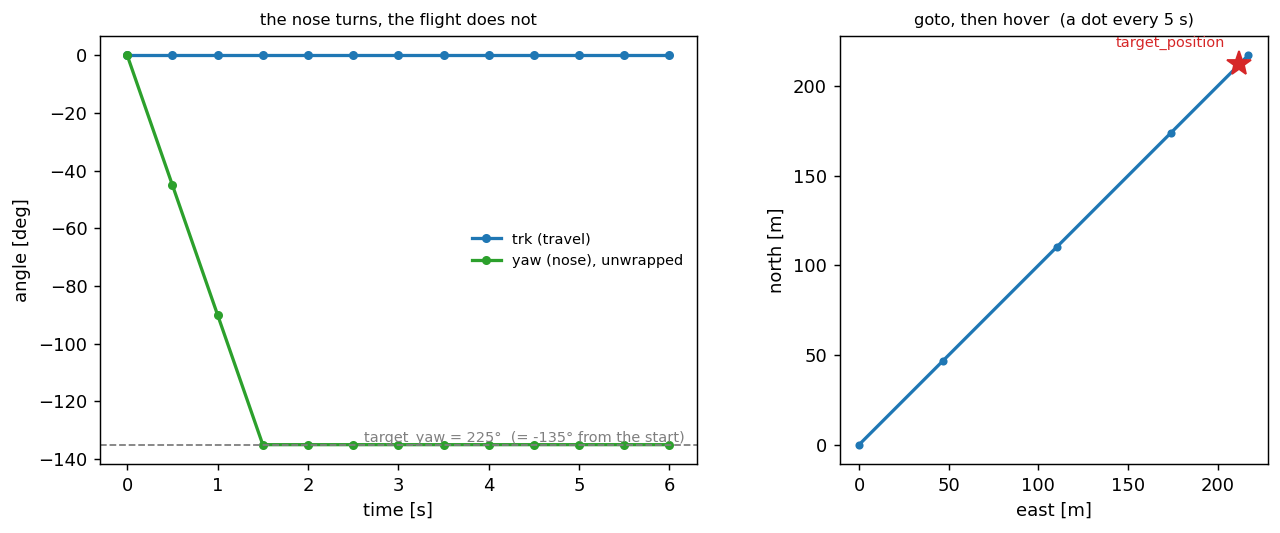

In [7]:
fig, (ax_y, ax_g) = plt.subplots(1, 2, figsize=(10.6, 4.2))

ts = np.arange(len(turning)) * DT
# unwrap the yaw: 0 -> 315 -> 270 is three steps of -45 deg, not a jump of +315
yaw_unwrapped = np.degrees(np.unwrap(np.radians([s.yaw for s in turning])))
ax_y.plot(ts, [s.trk for s in turning], marker="o", ms=4, lw=1.8, color=BLUE, label="trk (travel)")
ax_y.plot(ts, yaw_unwrapped, marker="o", ms=4, lw=1.8, color=GREEN, label="yaw (nose), unwrapped")
ax_y.axhline(yaw_unwrapped[-1], ls="--", lw=1.0, color=GREY)
ax_y.annotate("target_yaw = 225°  (= -135° from the start)", (0.98, yaw_unwrapped[-1]),
              xycoords=("axes fraction", "data"), ha="right", va="bottom", fontsize=8, color=GREY)
ax_y.set_xlabel("time [s]")
ax_y.set_ylabel("angle [deg]")
ax_y.set_title("the nose turns, the flight does not", fontsize=9)
ax_y.legend(frameon=False, fontsize=8, loc="center right")

goto_xy = np.array([geo.enu(52.0, 4.0, s.lat, s.lon) for s in goto])
tgt_xy = geo.enu(52.0, 4.0, *target)
ax_g.plot(goto_xy[:, 0], goto_xy[:, 1], lw=1.8, color=BLUE)
ax_g.plot(goto_xy[::5, 0], goto_xy[::5, 1], ls="none", marker="o", ms=3.5, color=BLUE)
ax_g.plot(*tgt_xy, marker="*", ms=14, color=RED)
ax_g.annotate("target_position", tgt_xy, (-8, 10), textcoords="offset points", fontsize=8,
              color=RED, ha="right")
ax_g.set_aspect("equal")
ax_g.set_xlabel("east [m]")
ax_g.set_ylabel("north [m]")
ax_g.set_title("goto, then hover  (a dot every 5 s)", fontsize=9)
fig.tight_layout()

## 6. Command in the body frame

`target_body_velocity` is `(forward, right)` along the current nose. The model resolves it through
`yaw`, so "forward" is a fixed world direction only when the yaw says so. It takes precedence over
`target_velocity`.

In [8]:
print(f"{'yaw [deg]':>11}{'command':>22}{'flown trk [deg]':>18}{'gs [m/s]':>11}")
for yaw in (0.0, 90.0, 180.0, 270.0):
    state = dataclasses.replace(from_rest, yaw=yaw)
    out = MR.step(state, MotionCommand(target_body_velocity=(5.0, 0.0)), M600, dt=1.0)
    print(f"{yaw:>11.0f}{'forward 5, right 0':>22}{out.trk:>18.1f}{out.gs:>11.2f}")

print()
sideways = MR.step(dataclasses.replace(from_rest, yaw=0.0),
                   MotionCommand(target_body_velocity=(0.0, 5.0)), M600, dt=1.0)
print(f"nose north, 'right 5' flies trk {sideways.trk:.1f} deg — a multirotor flies sideways")

  yaw [deg]               command   flown trk [deg]   gs [m/s]
          0    forward 5, right 0               0.0       5.00
         90    forward 5, right 0              90.0       5.00
        180    forward 5, right 0             180.0       5.00
        270    forward 5, right 0             270.0       5.00

nose north, 'right 5' flies trk 90.0 deg — a multirotor flies sideways


## Do it yourself

1. Change `ax` on a copy of `M600` to 1.0 m/s² with `dataclasses.replace`. Run section 3 again and
   count the steps to `v_max`.
2. Command `-10.0` m/s in section 3. The M600 has a negative `v_min`, so it can fly backward.
3. Halve `dt` in section 4 to 0.25 s. Check that the nose takes the same number of **seconds**, not
   the same number of steps.
4. Move the target of section 5 to 3000 m. Find how long it holds `v_max`.

## Check

1. What does a holonomic point mass permit that a fixed-wing cannot do? Name two things.
2. `step` is a pure function. What does that mean for the state you passed in?
3. Which two envelope fields shape the speed ramp of section 3?

## Next

`L1.6 — The fixed-wing kinematics`. You can fly the easy airframe. Next you fly the one that cannot
stop and cannot move sideways.